<a href="https://colab.research.google.com/github/gs0232/ml-a2-hanseg/blob/main/notebooks/a2_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab does not have SimpleITK preinstalled

!pip install -q SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.1 MB/s eta 0:00:00


In [ ]:
# download HaN-Seg Dataset to Google Colab machine

!wget -c -O /content/HaN-Seg.zip "https://zenodo.org/records/7442914/files/HaN-Seg.zip?download=1"
!ls -1h /content/HaN-Seg.zip
!md5sum /content/HaN-Seg.zip

--2026-09-01 09:32:27--  https://zenodo.org/records/7442914/files/HaN-Seg.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.184.98.114, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4938848306 (4.6G) [application/octet-stream]
Saving to: ‘/content/HaN-Seg.zip’

/content/HaN-Seg.zi 100%[===================>]   4.60G  9.45MB/s    in 14m 44s 

2026-09-01 09:47:16 (5.33 MB/s) - ‘/content/HaN-Seg.zip’ saved [4938848306/4938848306]

/content/HaN-Seg.zip
c3d3070de3034933a63031b73b9cf0fc  /content/HaN-Seg.zip


In [ ]:
# Unzip and find Dataset

!unzip -q /content/HaN-Seg.zip -d /content/
!find /content -maxdepth 3 -type d -name "case_01"

/content/HaN-Seg/set_1/case_01


In [ ]:
# Find Dataset content and relevant names

import os, glob

ROOT = "/content/HaN-Seg/set_1"

cases = sorted(glob.glob(os.path.join(ROOT, "case_*")))
print(len(cases), "cases found")

for i in sorted(os.listdir(cases[0])):
  print(" ", i)

42 cases found
  case_01_IMG_CT.nrrd
  case_01_IMG_MR_T1.nrrd
  case_01_OAR_A_Carotid_L.seg.nrrd
  case_01_OAR_A_Carotid_R.seg.nrrd
  case_01_OAR_Arytenoid.seg.nrrd
  case_01_OAR_Bone_Mandible.seg.nrrd
  case_01_OAR_Brainstem.seg.nrrd
  case_01_OAR_BuccalMucosa.seg.nrrd
  case_01_OAR_Cavity_Oral.seg.nrrd
  case_01_OAR_Cochlea_L.seg.nrrd
  case_01_OAR_Cochlea_R.seg.nrrd
  case_01_OAR_Cricopharyngeus.seg.nrrd
  case_01_OAR_Esophagus_S.seg.nrrd
  case_01_OAR_Eye_AL.seg.nrrd
  case_01_OAR_Eye_AR.seg.nrrd
  case_01_OAR_Eye_PL.seg.nrrd
  case_01_OAR_Eye_PR.seg.nrrd
  case_01_OAR_Glnd_Lacrimal_L.seg.nrrd
  case_01_OAR_Glnd_Lacrimal_R.seg.nrrd
  case_01_OAR_Glnd_Submand_L.seg.nrrd
  case_01_OAR_Glnd_Submand_R.seg.nrrd
  case_01_OAR_Glnd_Thyroid.seg.nrrd
  case_01_OAR_Glottis.seg.nrrd
  case_01_OAR_Larynx_SG.seg.nrrd
  case_01_OAR_Lips.seg.nrrd
  case_01_OAR_OpticChiasm.seg.nrrd
  case_01_OAR_OpticNrv_L.seg.nrrd
  case_01_OAR_OpticNrv_R.seg.nrrd
  case_01_OAR_Parotid_L.seg.nrrd
  case_01_OAR_Pa

42 patients with 32 filnames:

- 1x _IMG_CT.nrrd
- 1x _IMG_MR_T1.nrrd
- 30x Masks called _OAR_<name>.seg.nrrd
  - case_01_OAR_Cochlea_L.seg.nrrd
  - case_01_OAR_Cochlea_R.seg.nrrd
  - case_01_OAR_Parotid_L.seg.nrrd
  - case_01_OAR_Parotid_R.seg.nrrd

In [ ]:
# open CT and look at the numbers

import SimpleITK as sitk
import numpy as np

ct_path = glob.glob(os.path.join(cases[0], "*IMG_CT.nrrd"))[0]
ct = sitk.ReadImage(ct_path)
arr = sitk.GetArrayFromImage(ct) # gives back in mm in (z, y, x)

print("Array shape (slices, rows, columns):", arr.shape)
print("Voxel spacing in mm (x, y, z):", ct.GetSpacing())
print("Value range in Hounsfield units:", arr.min(), "to", arr.max())
#print("that is", arr.size(), "numbers, about", round(arr.nbytes / 1e6), "MB")

Array shape (slices, rows, columns): (202, 1024, 1024)
Voxel spacing in mm (x, y, z): (0.5576171875, 0.5576171875, 2.0)
Value range in Hounsfield units: -1000 to 3000


In [ ]:
# Determine actual size of Cochlea

coch_path = glob.glob(os.path.join(cases[0], "*Cochlea_L*"))[0]
coch = sitk.GetArrayFromImage(sitk.ReadImage(coch_path)) > 0

print("cochlea voxels :", int(coch.sum()))
print("whole volume   :", coch.size)
print("fraction       :", f"{100 * coch.sum() / coch.size:.5f} %")

cochlea voxels : 108
whole volume   : 211812352
fraction       : 0.00005 %


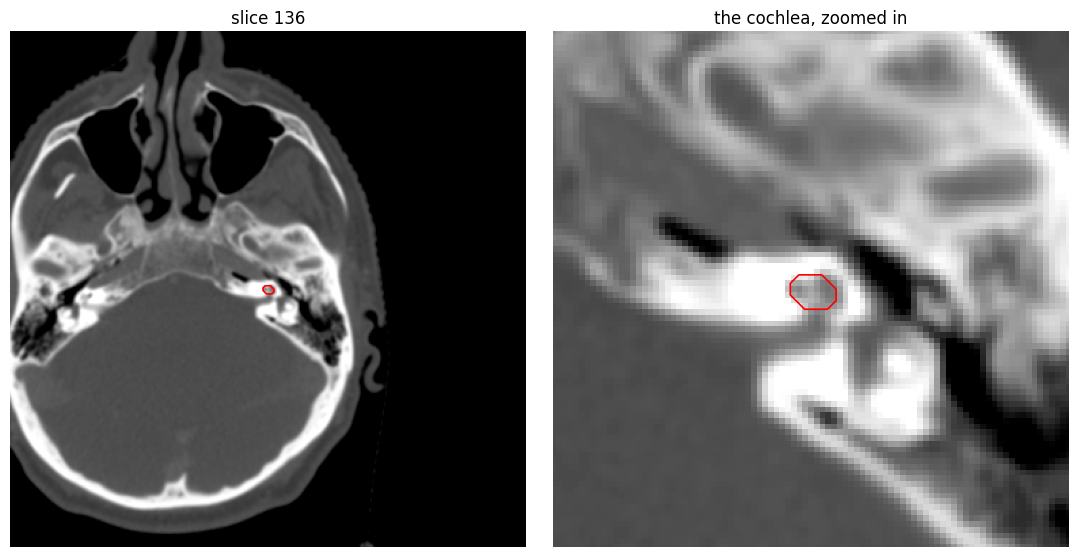

In [ ]:
# Look at data

import matplotlib.pyplot as plt

z = int(coch.sum(axis=(1, 2)).argmax()) # the slice with the most Cochlea in it
ys, xs = np.where(coch[z])
cy, cx = int(ys.mean()), int(xs.mean())

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
for a, half in zip(ax, [190, 45]):
    a.imshow(arr[z], cmap="gray", vmin=-500, vmax=1300)
    a.contour(coch[z], levels=[0.5], colors="red", linewidths=1.2)
    a.set_xlim(cx - half, cx + half)
    a.set_ylim(cy + half, cy - half)
    a.axis("off")
ax[0].set_title(f"slice {z}")
ax[1].set_title("the cochlea, zoomed in")
plt.tight_layout()
plt.show()